In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")

# Load the dataset
# Make sure the 'loan-train.csv' file is in the same directory as your notebook
df = pd.read_csv('/content/loan-train.csv')

# 1. Check the shape of the full dataset
print(f"Dataset Shape: {df.shape}")

# 2. View the first 5 rows to confirm data loaded correctly
print("\nFirst 5 rows:")
print(df.head())

# 3. Inspect columns, data types, and missing values
print("\nData Info:")
print(df.info())

# 4. Check for null values specifically
print("\nMissing Values Count:")
print(df.isnull().sum())

Dataset Shape: (614, 13)

First 5 rows:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         

In [ ]:
# 1. Drop Loan_ID
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

# 2. Handle 'Dependents' specifically (Based on your feedback)
# We replace "3+" with "3" to make it numeric.
# We map '0' to 0, '1' to 1, etc.
replace_dict = {'0': 0, '1': 1, '2': 2, '3+': 3}
df['Dependents'] = df['Dependents'].map(replace_dict)

# Now fill the missing 'Dependents' values with the mode (0)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

# Convert to integer now that no NaNs or text exist
df['Dependents'] = df['Dependents'].astype(int)

# 3. Fill missing values for other Categorical columns with Mode
cols_mode = ['Gender', 'Married', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in cols_mode:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 4. Fill missing values for Numerical columns with Median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# 5. Verify the clean state
print("Missing Values After Cleaning:")
print(df.isnull().sum())
print("\nDependents Value Counts:")
print(df['Dependents'].value_counts())

Missing Values After Cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Dependents Value Counts:
Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64


/tmp/ipython-input-870482766.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
/tmp/ipython-input-870482766.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [ ]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


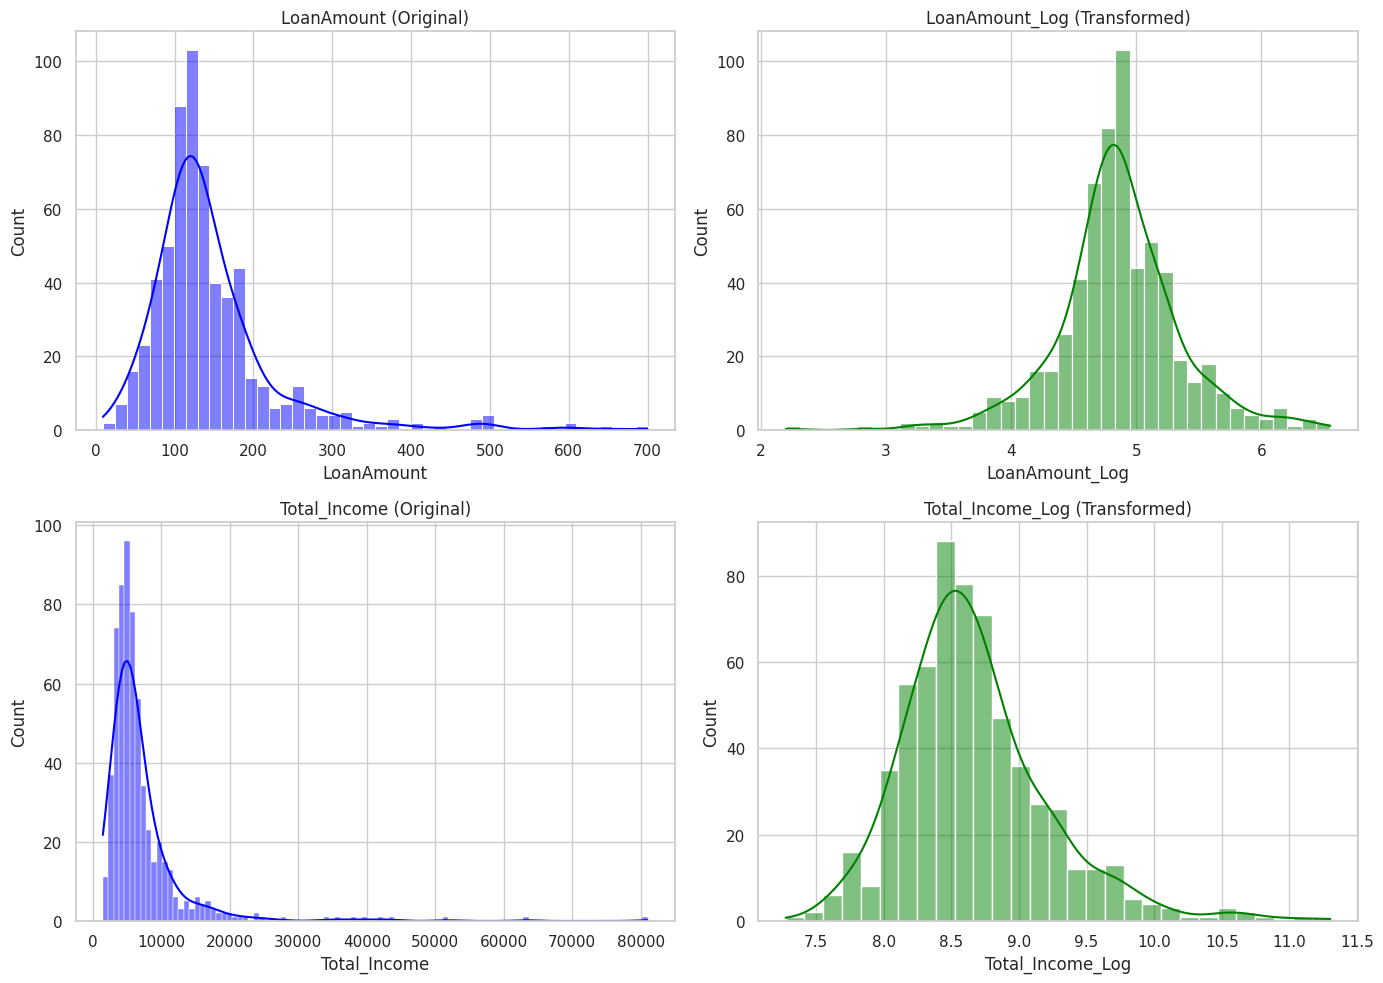


New Dataset Head:
  Gender Married  Dependents     Education Self_Employed  Loan_Amount_Term  \
0   Male      No           0      Graduate            No             360.0   
1   Male     Yes           1      Graduate            No             360.0   
2   Male     Yes           0      Graduate           Yes             360.0   
3   Male     Yes           0  Not Graduate            No             360.0   
4   Male      No           0      Graduate            No             360.0   

   Credit_History Property_Area Loan_Status  LoanAmount_Log  Total_Income_Log  
0             1.0         Urban           Y        4.852030          8.674026  
1             1.0         Rural           N        4.852030          8.714568  
2             1.0         Urban           Y        4.189655          8.006368  
3             1.0         Urban           Y        4.787492          8.505323  
4             1.0         Urban           Y        4.948760          8.699515  


In [ ]:
# 1. Create Total_Income feature
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# 2. Apply Log Transformation
# This handles the skewness (outliers) in the data
df['LoanAmount_Log'] = np.log(df['LoanAmount'])
df['Total_Income_Log'] = np.log(df['Total_Income'])

# 3. Visualize the difference (Original vs Log Transformed)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loan Amount before
sns.histplot(df['LoanAmount'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('LoanAmount (Original)')

# Loan Amount after
sns.histplot(df['LoanAmount_Log'], kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('LoanAmount_Log (Transformed)')

# Total Income before
sns.histplot(df['Total_Income'], kde=True, ax=axes[1, 0], color='blue')
axes[1, 0].set_title('Total_Income (Original)')

# Total Income after
sns.histplot(df['Total_Income_Log'], kde=True, ax=axes[1, 1], color='green')
axes[1, 1].set_title('Total_Income_Log (Transformed)')

plt.tight_layout()
plt.show()

# 4. Drop original columns (we only need the Log versions for the model)
cols_to_drop = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income']
df = df.drop(columns=cols_to_drop)

# 5. Check the new dataset structure
print("\nNew Dataset Head:")
print(df.head())

Class Distribution (Loan_Status):
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


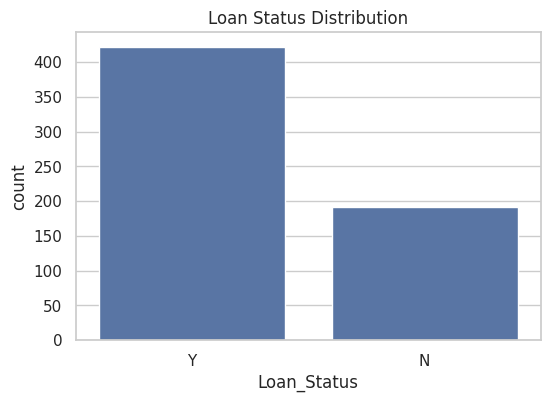


Data Types after Encoding:
Gender                int64
Married               int64
Dependents            int64
Education             int64
Self_Employed         int64
Loan_Amount_Term    float64
Credit_History      float64
Property_Area         int64
Loan_Status           int64
LoanAmount_Log      float64
Total_Income_Log    float64
dtype: object

Training Set Shape: (491, 10)
Testing Set Shape: (123, 10)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Check Class Imbalance
print("Class Distribution (Loan_Status):")
print(df['Loan_Status'].value_counts(normalize=True) * 100)

# Visualize the imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Status Distribution')
plt.show()

# 2. Label Encoding (Convert Text to Numbers)
# We use LabelEncoder for categorical variables
cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
le = LabelEncoder()

for col in cols:
    df[col] = le.fit_transform(df[col])

# Verify the conversion
print("\nData Types after Encoding:")
print(df.dtypes)

# 3. Define Features (X) and Target (y)
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# 4. Split into Train and Test sets (80% Train, 20% Test)
# random_state=42 ensures we get the same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Apply SMOTE to generate synthetic data for the minority class
# This balances the training set to 50% Approved / 50% Rejected
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Original Training Shape: {X_train.shape}")
print(f"Resampled (SMOTE) Training Shape: {X_train_smote.shape}")
print("-" * 30)

# 2. Define Hyperparameter Grids
# Note: We removed 'class_weight'/'scale_pos_weight' because SMOTE fixed the imbalance.

# Decision Tree Params
dt_params = {
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}

# Random Forest Params
rf_params = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 4),
    'bootstrap': [True, False]
}

# XGBoost Params
xgb_params = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5)
}

# 3. Setup Models & Search
models_to_tune = {
    "Decision Tree": (DecisionTreeClassifier(random_state=42), dt_params),
    "Random Forest": (RandomForestClassifier(random_state=42), rf_params),
    "XGBoost": (XGBClassifier(eval_metric='logloss', random_state=42), xgb_params)
}

# 4. Run Tuning Loop
for name, (model, params) in models_to_tune.items():
    print(f"Tuning {name} with SMOTE data...")

    search = RandomizedSearchCV(
        model,
        param_distributions=params,
        n_iter=20,
        cv=5,
        scoring='f1_macro', # Still optimizing for balance
        n_jobs=-1,
        random_state=42
    )

    # Fit on the SMOTE Data
    search.fit(X_train_smote, y_train_smote)

    # Evaluate on the original (unseen) Test Data
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    print(f"\n--- Best {name} Results ---")
    print(f"Best Params: {search.best_params_}")
    print(classification_report(y_test, y_pred))
    print("=" * 40)

Original Training Shape: (491, 10)
Resampled (SMOTE) Training Shape: (684, 10)
------------------------------
Tuning Decision Tree with SMOTE data...

--- Best Decision Tree Results ---
Best Params: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 5, 'min_samples_split': 2}
              precision    recall  f1-score   support

           0       0.52      0.60      0.56        43
           1       0.77      0.70      0.73        80

    accuracy                           0.67       123
   macro avg       0.64      0.65      0.65       123
weighted avg       0.68      0.67      0.67       123

Tuning Random Forest with SMOTE data...

--- Best Random Forest Results ---
Best Params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 158}
              precision    recall  f1-score   support

           0       0.68      0.49      0.57        43
           1       0.76      0.88      0.81        80

    accuracy            

/tmp/ipython-input-1847631933.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


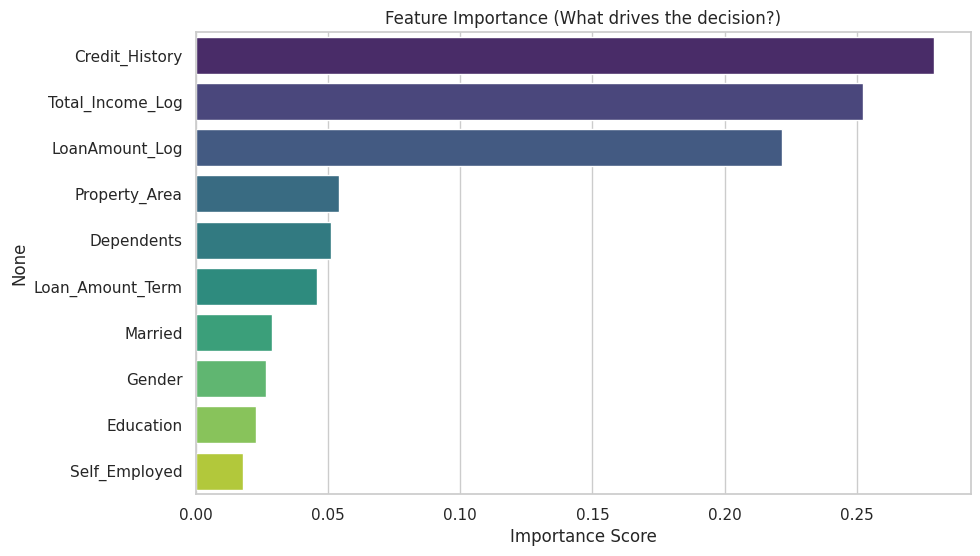

--- Impact of Threshold Moving on Safety (Recall Class 0) ---
Threshold: 0.4 | Recall (Class 0): 0.42 | Caught 18/43 Bad Loans
Threshold: 0.5 | Recall (Class 0): 0.47 | Caught 20/43 Bad Loans
Threshold: 0.6 | Recall (Class 0): 0.53 | Caught 22/43 Bad Loans
Threshold: 0.7 | Recall (Class 0): 0.60 | Caught 26/43 Bad Loans

--- Final Report with Threshold = 0.6 ---
              precision    recall  f1-score   support

           0       0.51      0.53      0.52        43
           1       0.74      0.72      0.73        80

    accuracy                           0.66       123
   macro avg       0.63      0.63      0.63       123
weighted avg       0.66      0.66      0.66       123



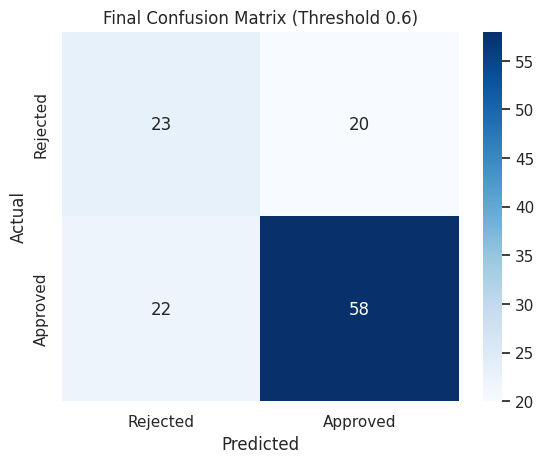

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score

# 1. Re-train the Best Random Forest with the parameters found in the previous step
# These params are from your output for "Best Random Forest"
best_rf = RandomForestClassifier(
    bootstrap=False,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=158,
    random_state=42
)

best_rf.fit(X_train_smote, y_train_smote)

# 2. Feature Importance Plot
importances = best_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title("Feature Importance (What drives the decision?)")
plt.xlabel("Importance Score")
plt.show()

# 3. Threshold Tuning (The Magic Step)
# Get the probability of "Approval" (Class 1) for the test set
y_probs = best_rf.predict_proba(X_test)[:, 1]

print("--- Impact of Threshold Moving on Safety (Recall Class 0) ---")
thresholds = [0.4, 0.5, 0.6, 0.7]

for t in thresholds:
    # If prob > t, predict 1 (Approve), else 0 (Reject)
    y_pred_adj = (y_probs >= t).astype(int)

    # Calculate Recall for Rejections (Class 0)
    recall_0 = recall_score(y_test, y_pred_adj, pos_label=0)
    print(f"Threshold: {t:.1f} | Recall (Class 0): {recall_0:.2f} | Caught {int(recall_0 * 43)}/43 Bad Loans")

# 4. Final Classification Report with a Safer Threshold (e.g., 0.6)
print("\n--- Final Report with Threshold = 0.6 ---")
y_pred_final = (y_probs >= 0.6).astype(int)
print(classification_report(y_test, y_pred_final))

# Confusion Matrix for the final model
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix (Threshold 0.6)')
plt.show()

In [ ]:
from sklearn.ensemble import VotingClassifier

# 1. Create the "Golden Feature": Ability to Pay
# (Total Income / Loan Amount). Higher is better.
# We use the log values we already have to keep scales similar
df['Ability_to_Pay'] = df['Total_Income_Log'] - df['LoanAmount_Log']

# 2. Re-define X and y with the new feature
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# 3. Re-split and Re-SMOTE (Essential since X changed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 4. Define the Best Models (using the best params we found earlier)
# Random Forest (from your Cell 7 output)
rf_best = RandomForestClassifier(
    bootstrap=False, max_depth=None, min_samples_leaf=1,
    min_samples_split=2, n_estimators=158, random_state=42
)

# XGBoost (from your Cell 7 output)
xgb_best = XGBClassifier(
    colsample_bytree=0.84, gamma=0.07, learning_rate=0.1,
    max_depth=9, n_estimators=289, subsample=0.64,
    eval_metric='logloss', random_state=42
)

# 5. Create Voting Classifier (Soft Voting = Average of probabilities)
voting_clf = VotingClassifier(
    estimators=[('rf', rf_best), ('xgb', xgb_best)],
    voting='soft'
)

print("Training Voting Classifier with new features...")
voting_clf.fit(X_train_smote, y_train_smote)

# 6. Evaluate
print("\n--- Voting Classifier Results (Threshold 0.5) ---")
y_pred = voting_clf.predict(X_test)
print(classification_report(y_test, y_pred))

# 7. Check Threshold Moving on the Ensemble
y_probs_vote = voting_clf.predict_proba(X_test)[:, 1]
print("\n--- Ensemble Threshold Moving (Recall Class 0) ---")
for t in [0.5, 0.6, 0.7]:
    recall_0 = recall_score(y_test, (y_probs_vote >= t).astype(int), pos_label=0)
    print(f"Threshold: {t:.1f} | Recall (Class 0): {recall_0:.2f}")

Training Voting Classifier with new features...

--- Voting Classifier Results (Threshold 0.5) ---
              precision    recall  f1-score   support

           0       0.63      0.56      0.59        43
           1       0.78      0.82      0.80        80

    accuracy                           0.73       123
   macro avg       0.70      0.69      0.70       123
weighted avg       0.73      0.73      0.73       123


--- Ensemble Threshold Moving (Recall Class 0) ---
Threshold: 0.5 | Recall (Class 0): 0.56
Threshold: 0.6 | Recall (Class 0): 0.58
Threshold: 0.7 | Recall (Class 0): 0.60


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Define the Base Models (The Experts)
# We use the tuned versions we found earlier
estimators = [
    ('rf', RandomForestClassifier(
        bootstrap=False, max_depth=None, min_samples_leaf=1,
        min_samples_split=2, n_estimators=158, random_state=42
    )),
    ('xgb', XGBClassifier(
        colsample_bytree=0.84, gamma=0.07, learning_rate=0.1,
        max_depth=9, n_estimators=289, subsample=0.64,
        eval_metric='logloss', random_state=42
    ))
]

# 2. Define the Stacking Classifier (The Judge)
# The 'final_estimator' uses the predictions of RF and XGB as inputs
clf_stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5  # Cross-validation for training the meta-model
)

print("Training Stacking Classifier (This usually takes longer)...")
clf_stack.fit(X_train_smote, y_train_smote)

# 3. Evaluate
print("\n--- Stacking Classifier Results ---")
y_pred_stack = clf_stack.predict(X_test)
print(classification_report(y_test, y_pred_stack))

# 4. Check Threshold Moving for Stacking
y_probs_stack = clf_stack.predict_proba(X_test)[:, 1]
print("\n--- Stacking Threshold Moving (Recall Class 0) ---")
for t in [0.5, 0.6, 0.7]:
    # Predict 1 only if probability > t
    y_pred_t = (y_probs_stack >= t).astype(int)
    recall_0 = recall_score(y_test, y_pred_t, pos_label=0)
    acc = accuracy_score(y_test, y_pred_t)
    print(f"Threshold: {t:.1f} | Recall (Class 0): {recall_0:.2f} | Accuracy: {acc:.2f}")

Training Stacking Classifier (This usually takes longer)...

--- Stacking Classifier Results ---
              precision    recall  f1-score   support

           0       0.61      0.53      0.57        43
           1       0.76      0.81      0.79        80

    accuracy                           0.72       123
   macro avg       0.68      0.67      0.68       123
weighted avg       0.71      0.72      0.71       123


--- Stacking Threshold Moving (Recall Class 0) ---
Threshold: 0.5 | Recall (Class 0): 0.53 | Accuracy: 0.72
Threshold: 0.6 | Recall (Class 0): 0.56 | Accuracy: 0.67
Threshold: 0.7 | Recall (Class 0): 0.58 | Accuracy: 0.62


In [ ]:
import joblib
import pandas as pd
import numpy as np

# 1. Save the best model (Voting Classifier) to a file
joblib.dump(voting_clf, 'loan_voting_model.pkl')
print("Model saved successfully as 'loan_voting_model.pkl'")

# 2. Define the Prediction Function
def predict_loan_status(gender, married, dependents, education, self_employed,
                        applicant_income, coapplicant_income, loan_amount,
                        loan_term, credit_history, property_area):

    # A. Create a DataFrame from input
    data = pd.DataFrame({
        'Gender': [gender],
        'Married': [married],
        'Dependents': [dependents],
        'Education': [education],
        'Self_Employed': [self_employed],
        'Loan_Amount_Term': [loan_term],
        'Credit_History': [credit_history],
        'Property_Area': [property_area],
        'ApplicantIncome': [applicant_income],
        'CoapplicantIncome': [coapplicant_income],
        'LoanAmount': [loan_amount]
    })

    # B. Handle Categorical Encoding (Manually mapping to ensure consistency)
    # These mappings must match what LabelEncoder did alphabetically
    data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})
    data['Married'] = data['Married'].map({'Yes': 1, 'No': 0})
    data['Education'] = data['Education'].map({'Not Graduate': 1, 'Graduate': 0})
    data['Self_Employed'] = data['Self_Employed'].map({'Yes': 1, 'No': 0})
    data['Property_Area'] = data['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})

    # Handle Dependents (3+ case)
    if isinstance(dependents, str) and dependents == '3+':
        data['Dependents'] = 3
    else:
        data['Dependents'] = int(dependents)

    # C. Feature Engineering (Log Transforms & Ratios)
    # Total Income
    total_income = data['ApplicantIncome'] + data['CoapplicantIncome']
    data['Total_Income_Log'] = np.log(total_income)

    # Loan Amount Log
    data['LoanAmount_Log'] = np.log(data['LoanAmount'])

    # The Golden Feature: Ability to Pay
    data['Ability_to_Pay'] = data['Total_Income_Log'] - data['LoanAmount_Log']

    # Drop original raw columns to match Model's expected input (X)
    # Expected cols: Gender, Married, Dependents, Education, Self_Employed,
    # Loan_Amount_Term, Credit_History, Property_Area, LoanAmount_Log, Total_Income_Log, Ability_to_Pay
    features = data[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
                     'Loan_Amount_Term', 'Credit_History', 'Property_Area',
                     'LoanAmount_Log', 'Total_Income_Log', 'Ability_to_Pay']]

    # D. Make Prediction
    # We use the threshold of 0.6 (Safety First!)
    prob_approval = voting_clf.predict_proba(features)[0][1]

    threshold = 0.6
    status = "APPROVED" if prob_approval >= threshold else "REJECTED"

    return status, prob_approval

# 3. Test Case: "The Ideal Candidate"
# Male, Married, Graduate, High Income, Good Credit
status, prob = predict_loan_status(
    gender='Male', married='Yes', dependents=0, education='Graduate', self_employed='No',
    applicant_income=6000, coapplicant_income=2000, loan_amount=120,
    loan_term=360, credit_history=1.0, property_area='Semiurban'
)
print(f"Test Case 1 (Ideal): {status} (Confidence: {prob:.2%})")

# 4. Test Case: "Risky Candidate"
# Male, Low Income, Bad Credit
status, prob = predict_loan_status(
    gender='Male', married='Yes', dependents=2, education='Not Graduate', self_employed='No',
    applicant_income=2500, coapplicant_income=0, loan_amount=150,
    loan_term=360, credit_history=0.0, property_area='Rural'
)
print(f"Test Case 2 (Risky): {status} (Confidence: {prob:.2%})")

Model saved successfully as 'loan_voting_model.pkl'
Test Case 1 (Ideal): APPROVED (Confidence: 97.46%)
Test Case 2 (Risky): REJECTED (Confidence: 4.44%)


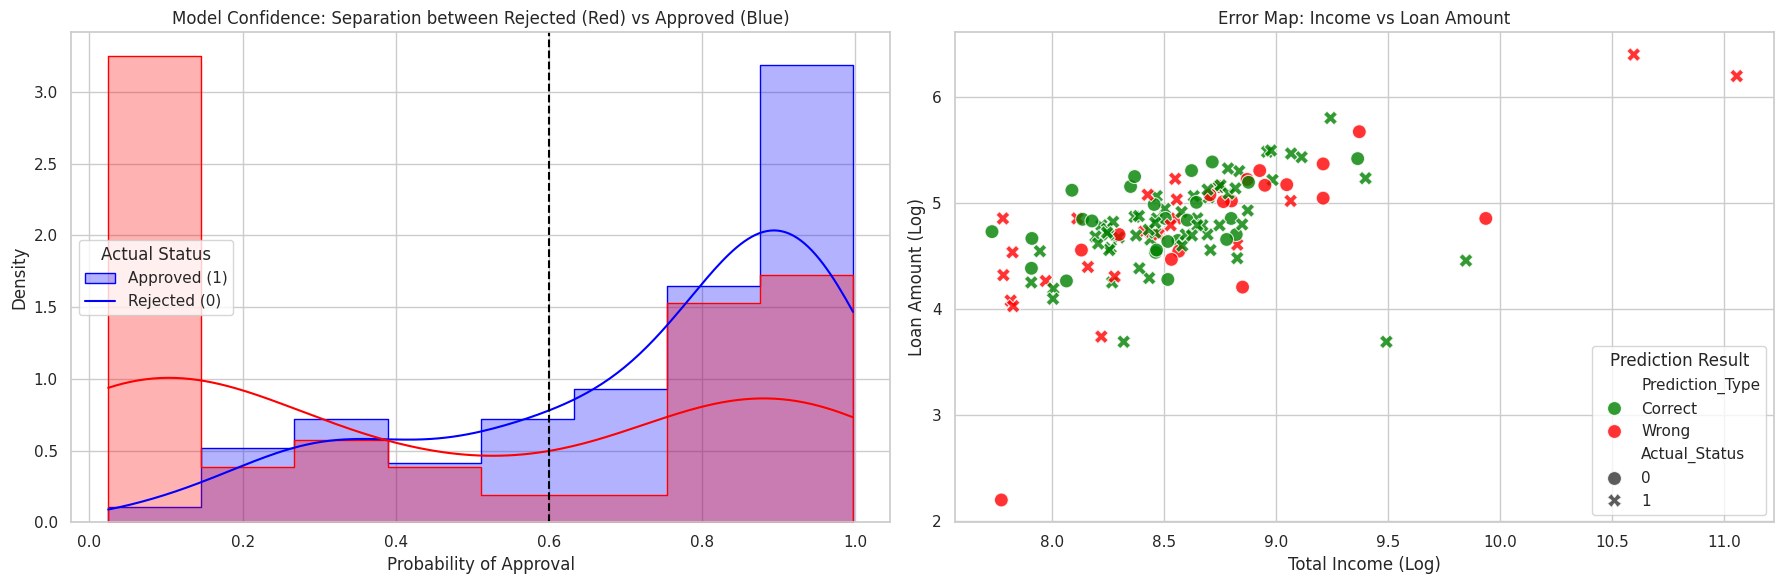

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare Data for Visualization
# We use the X_test data we already have
viz_df = X_test.copy()
viz_df['Actual_Status'] = y_test
viz_df['Predicted_Prob'] = voting_clf.predict_proba(X_test)[:, 1]
# Apply our chosen threshold (0.6)
viz_df['Predicted_Status'] = (viz_df['Predicted_Prob'] >= 0.6).astype(int)
# Determine if the prediction was Correct or Wrong
viz_df['Prediction_Type'] = viz_df.apply(
    lambda x: 'Correct' if x['Actual_Status'] == x['Predicted_Status'] else 'Wrong', axis=1
)

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Probability Distribution (How confident is the model?) ---
# We want to see two distinct mountains: One for Actual 0 (Reject) and one for Actual 1 (Approve)
sns.histplot(
    data=viz_df, x='Predicted_Prob', hue='Actual_Status',
    element="step", stat="density", common_norm=False, kde=True,
    palette={0: 'red', 1: 'blue'}, alpha=0.3, ax=axes[0]
)
axes[0].axvline(0.6, color='black', linestyle='--', label='Threshold (0.6)')
axes[0].set_title('Model Confidence: Separation between Rejected (Red) vs Approved (Blue)')
axes[0].set_xlabel('Probability of Approval')
axes[0].legend(title='Actual Status', labels=['Approved (1)', 'Rejected (0)'])


# --- Plot 2: The Error Map (Where does it fail?) ---
# We plot Total Income vs Loan Amount (the two big money factors)
# Green = Correct Prediction, Red = Wrong Prediction
sns.scatterplot(
    data=viz_df, x='Total_Income_Log', y='LoanAmount_Log',
    hue='Prediction_Type', style='Actual_Status',
    palette={'Correct': 'green', 'Wrong': 'red'},
    s=100, alpha=0.8, ax=axes[1]
)
axes[1].set_title('Error Map: Income vs Loan Amount')
axes[1].set_xlabel('Total Income (Log)')
axes[1].set_ylabel('Loan Amount (Log)')
axes[1].legend(title='Prediction Result')

plt.tight_layout()
plt.show()

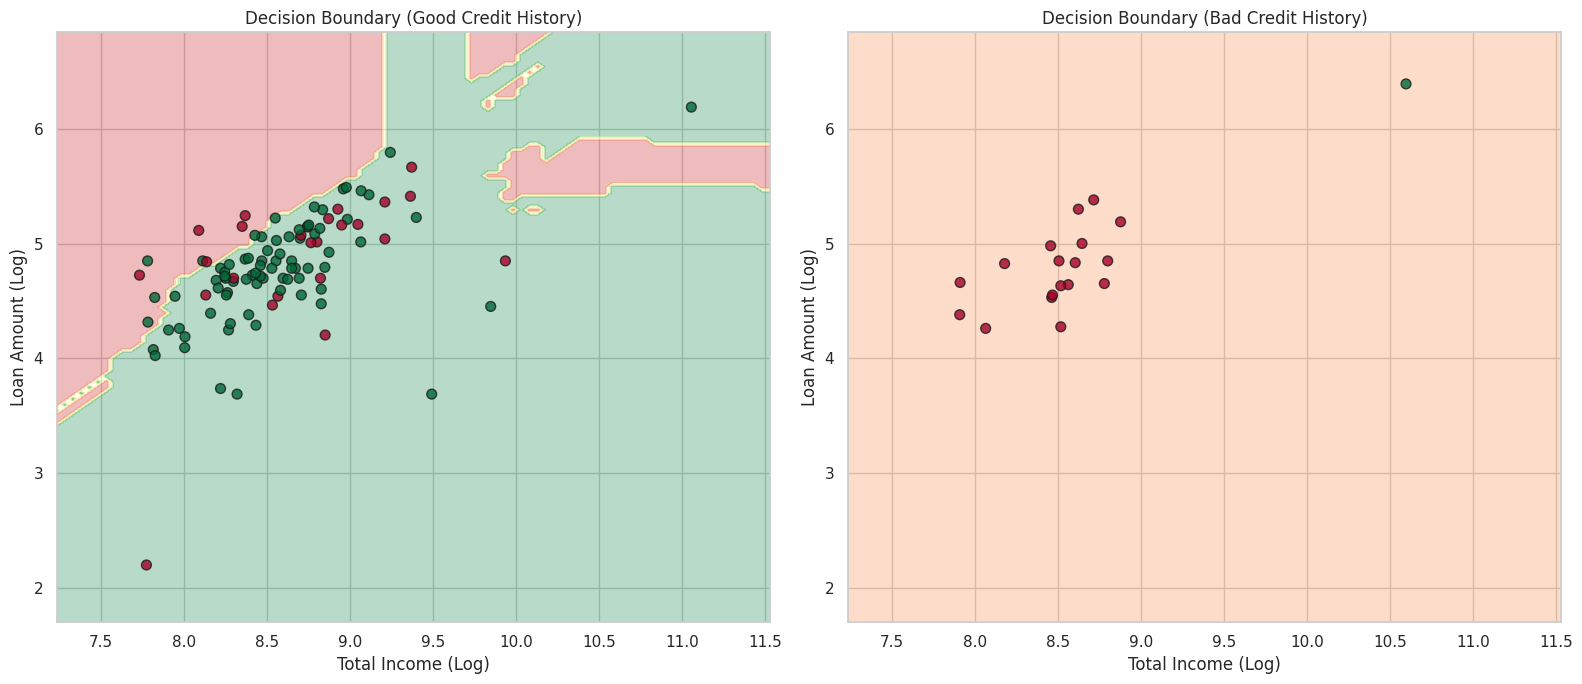

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_custom_boundary(model, X_data, y_data, credit_history_status, ax, title):
    # 1. Define the range for the grid (Income vs Loan Amount)
    x_min, x_max = X_data['Total_Income_Log'].min() - 0.5, X_data['Total_Income_Log'].max() + 0.5
    y_min, y_max = X_data['LoanAmount_Log'].min() - 0.5, X_data['LoanAmount_Log'].max() + 0.5

    # Create the meshgrid (100x100 points)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))

    # 2. Create a template for the model input (11 features)
    # We repeat the default profile for every point in the meshgrid
    # Default Profile: Male(1), Married(1), Dependents(0), Graduate(0), Self_Employed(0), Term(360), Urban(2)
    rows = xx.ravel().shape[0]

    # Columns order must match X_train exactly:
    # ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
    #  'Loan_Amount_Term', 'Credit_History', 'Property_Area',
    #  'LoanAmount_Log', 'Total_Income_Log', 'Ability_to_Pay']

    grid_data = pd.DataFrame({
        'Gender': np.ones(rows),             # Male
        'Married': np.ones(rows),            # Married
        'Dependents': np.zeros(rows),        # 0 Dependents
        'Education': np.zeros(rows),         # Graduate (0)
        'Self_Employed': np.zeros(rows),     # No
        'Loan_Amount_Term': np.full(rows, 360),
        'Credit_History': np.full(rows, credit_history_status), # <--- We vary this
        'Property_Area': np.full(rows, 2),   # Urban
        'LoanAmount_Log': yy.ravel(),        # Y-axis variable
        'Total_Income_Log': xx.ravel(),      # X-axis variable
    })

    # CRITICAL: Recalculate 'Ability_to_Pay' derived feature for the grid
    grid_data['Ability_to_Pay'] = grid_data['Total_Income_Log'] - grid_data['LoanAmount_Log']

    # Reorder columns to match model training input
    grid_data = grid_data[X_data.columns]

    # 3. Predict for the grid
    Z = model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    # 4. Plot Contours
    # Red for Reject (0), Green for Approve (1)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlGn)

    # 5. Overlay the ACTUAL data points (only those matching the Credit History we are plotting)
    mask = X_data['Credit_History'] == credit_history_status

    # Scatter plot:
    # Use 'c' (color) for the ACTUAL Status (y_data)
    # Edgecolors makes them pop
    ax.scatter(X_data.loc[mask, 'Total_Income_Log'],
               X_data.loc[mask, 'LoanAmount_Log'],
               c=y_data[mask],
               cmap=plt.cm.RdYlGn, edgecolors='k', s=50, alpha=0.8)

    ax.set_xlabel('Total Income (Log)')
    ax.set_ylabel('Loan Amount (Log)')
    ax.set_title(title)

# --- Execute Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: People with GOOD Credit History (1.0)
plot_custom_boundary(voting_clf, X_test, y_test, 1.0, axes[0], "Decision Boundary (Good Credit History)")

# Plot 2: People with BAD Credit History (0.0)
plot_custom_boundary(voting_clf, X_test, y_test, 0.0, axes[1], "Decision Boundary (Bad Credit History)")

plt.tight_layout()
plt.show()

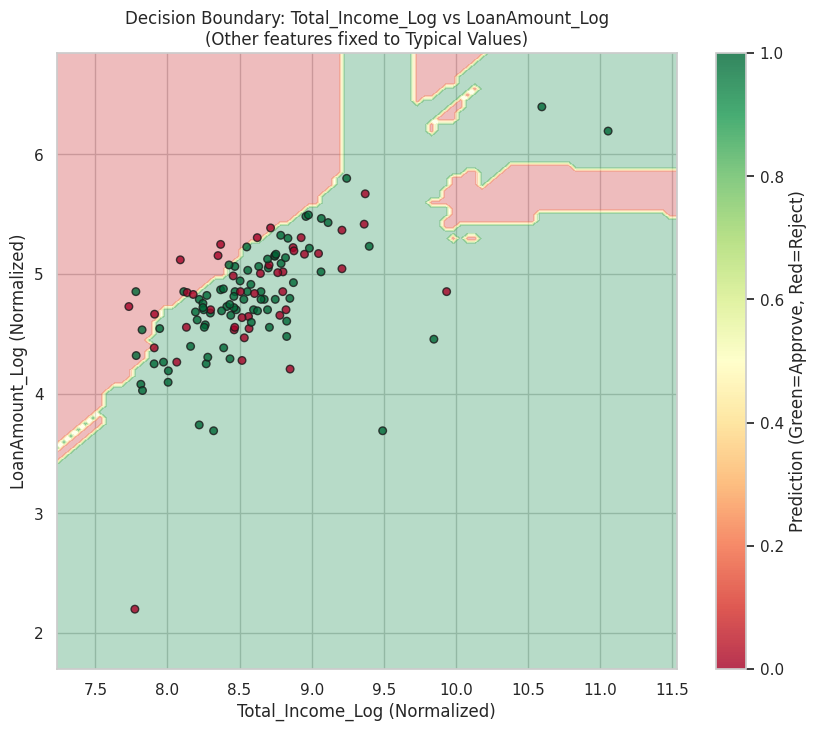

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_decision_boundary(model, X, y, x_col, y_col):
    """
    Plots the decision boundary by slicing the hypercube.
    It varies 'x_col' and 'y_col' while keeping other features fixed to their Mode/Median.
    """
    plt.figure(figsize=(10, 8))

    # 1. Create Meshgrid for the two features we want to visualize
    # We add +/- 0.5 padding to see the edges clearly
    x_min, x_max = X[x_col].min() - 0.5, X[x_col].max() + 0.5
    y_min, y_max = X[y_col].min() - 0.5, X[y_col].max() + 0.5
    h = 0.05  # Step size for resolution
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 2. Construct the full input matrix (11 features)
    rows = xx.ravel().shape[0]

    # Create a "Template" row using the Mode (most frequent value) of every column
    # This represents the "Average Customer"
    fixed_values = X.mode().iloc[0]

    # Replicate this template for every point in our grid
    grid_data = pd.DataFrame([fixed_values] * rows, columns=X.columns)

    # 3. Overwrite the two columns we are varying
    grid_data[x_col] = xx.ravel()
    grid_data[y_col] = yy.ravel()

    # 4. CRITICAL: Update derived features
    # Since 'Ability_to_Pay' depends on Income and Loan, we must recalculate it
    # for every point in the grid, otherwise the model sees inconsistent data.
    if 'Ability_to_Pay' in grid_data.columns:
        grid_data['Ability_to_Pay'] = grid_data['Total_Income_Log'] - grid_data['LoanAmount_Log']

    # 5. Predict using the model
    Z = model.predict(grid_data)
    Z = Z.reshape(xx.shape)

    # 6. Plotting
    # Contour: The background colors (Red/Green zones)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlGn)

    # Scatter: The actual test data points
    plt.scatter(X[x_col], X[y_col], c=y, edgecolors='k', s=30, cmap=plt.cm.RdYlGn, alpha=0.8)

    plt.xlabel(f"{x_col} (Normalized)")
    plt.ylabel(f"{y_col} (Normalized)")
    plt.title(f"Decision Boundary: {x_col} vs {y_col}\n(Other features fixed to Typical Values)")
    plt.colorbar(label="Prediction (Green=Approve, Red=Reject)")
    plt.show()

# --- Run the Plot ---
# We visualize the two most important continuous variables
plot_decision_boundary(voting_clf, X_test, y_test, 'Total_Income_Log', 'LoanAmount_Log')